In [ ]:
#spark.stop()

##**Project Introduction**

The project focuses on building a large scale data pipeline using **MovieLens 100k** dataset provided by GroupLens Research.

The dataset comprises of 100,000 ratings on a 1-5 scale from 943 users across 1,682 movies.

To simulate a real-world enterprise Big Data environment, the study used a Hybrid Cloud Architecture. The Extract, Transform, Load (ETL) pipeline is fully managed using the distributed computing capabilities of Apache Spark 4.0.3.

The analytical insights are then stored across two distinct cloud-based NoSQL database to support diverse businee use cases.

##**Project Objective**

1.   To identify the top 10 highest rated movies with a minimum of 20 ratings and coduct a deep-dive demographic profiling of the viewers by analysing variables such as gender, age, occupation, watching timelines ad geographich locations.
2.   To isolate important users whom have rated at least 50 movies and mathematically determine their favourite movie genre based on their rating history.
3.   Perform NoSQL Data Persistence Integration:

     *   MongoDB Atlas (Cloud): Export document-structured data (JSON) regarding user favourite genres for a real-time application access or dashboarding.
     *   DataStax Astra DB /Cassandra: Persist rekational columnar data concerning top-tier movie trends to handle low-latency, high analytical query workload.

##**Project System Architecture**

The infrastructure is engineered using a modern data engineering stack to ensure an optimal processing speeds and platform compatibility using tools below:


*   Distributed Compute Engine: **Apache Spark 4.0.3** (PySpark Classic & RDD APIs).
*   Language Runtime : **Python 3.12.13**
*   Cloud Database Layer: **MongoDB Atlas Cloud** (via native Python pymongo driver).
*   DataStax Astra DB Cloud **Cassandra**: Decoupled via lightweight Astra DB Data API and HTTP REST protocols.
*   Analytical & Geospatial Libraries: **Plotly Express, Pandas, pgeocode, Seaborn**



## **Data Loading and Inspection**

In [ ]:
#Firstly, let's import all the relevant libraries

import sys
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.sql.functions import col, count, desc, row_number
import pyspark.sql.functions as F

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots

spark = SparkSession.builder.appName("Movielens").master("local[*]").getOrCreate()

In [ ]:
# Next, Load Data via Spark RDD
u_data_spark = spark.sparkContext.textFile("u.data")
u_item_spark = spark.sparkContext.textFile("u.item")
u_user_spark = spark.sparkContext.textFile("u.user")

# Next, perform initial inspection
print("head u.data:", u_data_spark.take(3))
print("\nhead u.item:", u_item_spark.take(3))
print("\nhead u.user:", u_user_spark.take(3))


head u.data: ['196\t242\t3\t881250949', '186\t302\t3\t891717742', '22\t377\t1\t878887116']

head u.item: ['1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0', '2|GoldenEye (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0', '3|Four Rooms (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0']

head u.user: ['1|24|M|technician|85711', '2|53|F|other|94043', '3|23|M|writer|32067']


Based on the printed output, the row schemas are as followss:

**u.data (Tab-delimited)**:
> This represents the transaction logs of when a user rated a specific movie.

> Hence, each record follows the structure of *['user_id\titem_id\trating\ttimestamp']*.

**u.item (Pipe-delimited)**:
> Contains movie metadata.

> Hence, each record follows the structure of *The first few attributes map to [movie_id | movie_title | release_date | video_release_date | IMDb_URL | ... binary genre flags].*

**u.user (Pipe-delimited)**:
> Contains user demographic metadata.

> Hence, each record follows the structure of *The first few attributes map to [user_id | age | gender | occupation | zip_code].*

For details, please read the data READ.ME

In [ ]:
# Next, convert data to dataframe

# u.data: Split guna '\t', take 1st 3 & change to integer
data_mapped = u_data_spark.map(lambda line: line.split('\t')).map(lambda x: (int(x[0]), int(x[1]), int(x[2]), int(x[3])))
df_data = spark.createDataFrame(data_mapped, ["user_id", "movie_id", "rating", "timestamp"])

# u.item: Split guna '|', take ID int & title string
item_mapped = u_item_spark.map(lambda line: line.split('|')).map(lambda x: (int(x[0]), x[1]))
df_item = spark.createDataFrame(item_mapped, ["movie_id", "title"])

# u.user: Split guna '|', take ID, Age, Gender, & Occupation
user_mapped = u_user_spark.map(lambda line: line.split('|')).map(lambda x: (int(x[0]), int(x[1]), x[2], x[3], x[4]))
df_user = spark.createDataFrame(user_mapped, ["user_id", "age", "gender", "occupation", "zip_code"])

## **Project Analysis using Apache Spark**

In [ ]:
# i. Calculate the average rating for each movie
movie_stats = df_data.groupBy("movie_id") \
    .agg(avg("rating").alias("avg_rating"), count("rating").alias("rating_count"))

*    To evaluate movie popularity, the transactional df_data dataframe is grouped by movie_id using the .groupBy() transformation.
*    Two parallel aggregations (.agg()) are computed: the statistical mean score using avg("rating") and the absolute engagement size using count("rating").
*    These values are aliased as avg_rating and rating_count respectively for structural clarity.

In [ ]:
# ii. Identify the top ten movies with the highest average ratings
top_10_movies = movie_stats.filter("rating_count >= 20") \
    .join(df_item, "movie_id") \
    .select("movie_id", "title", "avg_rating") \
    .orderBy(desc("avg_rating")).limit(10)

top_10_movies.show(truncate=False)

+--------+------------------------------------------------------+------------------+
|movie_id|title                                                 |avg_rating        |
+--------+------------------------------------------------------+------------------+
|408     |Close Shave, A (1995)                                 |4.491071428571429 |
|318     |Schindler's List (1993)                               |4.466442953020135 |
|169     |Wrong Trousers, The (1993)                            |4.466101694915254 |
|483     |Casablanca (1942)                                     |4.45679012345679  |
|114     |Wallace & Gromit: The Best of Aardman Animation (1996)|4.447761194029851 |
|64      |Shawshank Redemption, The (1994)                      |4.445229681978798 |
|603     |Rear Window (1954)                                    |4.3875598086124405|
|12      |Usual Suspects, The (1995)                            |4.385767790262173 |
|50      |Star Wars (1977)                                      |

*    Calculating a pure mathematical average can introduce statistical bias caused by niche items with very few ratings for example, a movie with a single 5-star rating would rank highest).
*    Hence, to establish a credible threshold, a threshold filter (.filter("rating_count >= 20")) is applied to isolate movies with at least 20 ratings.
*    Then, relational inner .join() is then executed against df_item matching on movie_id to fetch the human-readable movie titles.
*    The data is selected, sorted in descending order based on their rating (orderBy(desc("avg_rating"))), and constrained via .limit(10) to yield the final Top 10 collection.


In [ ]:
# Perform Interactive Visualization : Top ten movies with the highest average ratings

pdf_top10 = top_10_movies.toPandas()

fig1 = px.bar(
    pdf_top10,
    x="avg_rating",
    y="title",
    orientation='h',
    title="<b>Top 10 Movies with Highest Average Ratings</b> (Min 20 Ratings)",
    labels={"avg_rating": "Average Rating", "title": "Movie Title"},
    color="avg_rating",
    color_continuous_scale="rdylbu"  # <-- Dah ditukar ke huruf kecil / warna sah
)

fig1.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_range=[4.0, 5.0],
    title_font_size=16,
    hovermode="y"
)
fig1.show()

# **Code Interpretation**
-    To visualize the insights, the distributed Spark DataFrame is collected and converted to a local memory structure using .toPandas().
-    An interactive horizontal bar chart is rendered using Plotly Express, map-colored dynamically against the continuous avg_rating color scale.

## **Analytical Insights**

-    Close Shave, A (1995) ranks as the highest rated movie within the community criteria, holding the top average rating score of 4.49.
-    Then, followed closely by cinematic masterpieces Schindler's List (1993) and Wrong Trousers, The (1993), which are tied marginally at an average score of 4.47.
-   The well-known cult-classics such as Star Wars (1977) (avg: 4.36) and 12 Angry Men (1957) (avg: 4.34) successfully made it into the Top 10 leaderboard.
-   Hence, despite having higher overall watch counts across the entire dataset, their mathematical average remains highly stable when filtered against substantial community feedback.
-   There is a uniform high praise from the platform users towards these specific selections because all top ten movies reside within a narrow, competitive window ranging from 4.34 to 4.49 out of a maximum 5-star rating.
-   The analytical chart paves the way for the next critical question: What are the demographic patterns for example gender, age and occupation of the people who watch and drive the engagement for these top ten movies?"



In [ ]:
#get id list for each top 10 movie
top_10_movie_ids = [row['movie_id'] for row in top_10_movies.select("movie_id").collect()]

#filter df_data for this 10 film only
df_top10_viewers = df_data.filter(col("movie_id").isin(top_10_movie_ids)).join(df_user, "user_id")

print("1. Breakdown by Gender:")
df_top10_viewers.groupBy("gender") \
    .agg(count("rating").alias("total_views"), avg("rating").alias("avg_rating")) \
    .show()

print("2. Breakdown by Age:")
df_top10_viewers.agg(
    avg("age").alias("average_age")
).show()

print("3. Breakdown by Occupation:")
df_top10_viewers.groupBy("occupation") \
    .agg(count("rating").alias("total_views")) \
    .orderBy(desc("total_views")).limit(10) \
    .show()



1. Breakdown by Gender:
+------+-----------+-----------------+
|gender|total_views|       avg_rating|
+------+-----------+-----------------+
|     F|        544|          4.40625|
|     M|       1761|4.415105053946621|
+------+-----------+-----------------+

2. Breakdown by Age:
+-----------------+
|      average_age|
+-----------------+
|33.33318872017354|
+-----------------+

3. Breakdown by Occupation:
+-------------+-----------+
|   occupation|total_views|
+-------------+-----------+
|      student|        467|
|        other|        253|
|     educator|        223|
|   programmer|        202|
|     engineer|        202|
|administrator|        170|
|    librarian|        134|
|       writer|        109|
|   technician|         82|
|       artist|         69|
+-------------+-----------+



## **Code Interpretation**

- To extract demographic insights specifically for the top 10 movies, we first collect their distinct movie_id keys into a local Python list.
- We then apply a conditional lookup filter using .filter(col("movie_id").isin(top_10_movie_ids)) on the transaction log DataFrame (df_data).
- Then, an inner .join() operation is executed against the user metadata table (df_user) using the shared user_id as a foreign key.
- This consolidates user characteristics such as gender, age, and occupation with their actual viewing logs in a single operational table, df_top10_viewers.
- The script applies .groupBy("gender") paired with aggregate functions (`count("rating"), avg("rating")) to evaluate volume and qualitative sentiment by gender.
- For occupational tracking, the pipeline groups the data by `occupation`, aggregates the watch frequencies, dynamically sorts the stream in descending order via orderBy(desc("total_views")), and applies .limit(20) to capture an extended distribution of the top 20 occupational groups.


## **Analytical Insights**


#### A. Gender Distribution Profile

* Male users (**M**) heavily dominate the absolute viewership volume on the platform with **1,761 views**, whereas Female users (**F**) account for 544 views.
* Although the active audience base is predominantly male, both gender cohorts share an almost identical high-appreciation score for this selection of films (*Females avg: 4.41, Males avg: 4.42*).

> This empirical consistency demonstrates that the cinematic and thematic appeal of these top-rated films is highly universal, transcending gender biases regardless of the underlying sample size disparity.

---

#### B. Age Distribution Profile

* The mean age across all recorded views is approximately 33 years old.
* While a raw average of approximately 33 years implies a stable young-adult consumer base, relying solely on a single measure of central tendency can be statistically misleading.

> A single average figure can mask internal population variances, multi-modal behavior, or heavy data skewness. This data limitation fully justifies our next pipeline optimization: discretizing the continuous age variable into nominal binned cohorts (such as *18-24, 25-34, etc.*) to reveal the true statistical distribution profile.

---

#### C. Occupational Segmentation Profile

- The distribution of the top 20 occupational consumer segments is heavily led by students (467), followed by other (253), educator (223) programmer (202), and engineer (202), stretching down to secondary active professional groups like scientists, executives, marketing, and retired professionals.
-Students stand out as the single largest specialized demographic driver of engagement for top-tier films.
- When combined, tech-centric engineering roles (programmers and engineers) account for a massive combined engagement block (404 views), reflecting strong content resonance within the technical community.
- The generic label other stubbornly ranks as the second highest block (253 views). This placeholder entry is an unchangeable characteristic of the native dataset, meaning a large portion of users naturally preferred not to disclose a standardized corporate role during registration.

> Because the dataset inherently contains a massive, unchangeable "other" block at the top, expanding our console view to .limit(10) is highly necessary. It allows us to look past that giant placeholder and successfully capture a much wider landscape of distinct, highly-engaged professional subgroups—such as administrators, librarians, writers, technicians, artists, and retired citizens—which are highly valuable for platform targeting.

In [ ]:
df_age_groups = df_top10_viewers.withColumn(
    "age_group",
    when(col("age") < 18, "17 and below")
    .when((col("age") >= 18) & (col("age") <= 24), "18-24")
    .when((col("age") >= 25) & (col("age") <= 34), "25-34")
    .when((col("age") >= 35) & (col("age") <= 44), "35-44")
    .when((col("age") >= 45) & (col("age") <= 54), "45-54")
    .otherwise("55+")
)

# Code Interpretation

*   To resolve the insight limitation posed by a simple average age, the continuous variable age is bucketed into an nominal categorical bins.
*   We achieve this by appending a new feature column using .withColumn("age_group", ...) driven by conditional PySpark when() / .otherwise() logical routing.
*   This maps ages into standardized marketing cohorts: Under 18, 18-24, 25-34, 35-44, 45-54, and 55+.

> This structural enrichment sets up the pipeline perfectly for cross-tabulating age cohorts against time-based watching patterns (such as weekend vs. weekday behaviors).

In [ ]:
#probably we need to check this age group watched mostly when

# Extract hour from timestamp
df_with_day_names = df_age_groups.withColumn("day_name", date_format(from_unixtime(col("timestamp")), "EEEE"))


# Segment Name of week
df_day_type = df_with_day_names.withColumn(
    "day_type",
    when(col("day_name").isin("Saturday", "Sunday"), "Weekend")
    .otherwise("Weekday")
)

# Calcualte view for each age combination and TOD
pdf_age_day_type = df_day_type.groupBy("age_group", "day_type") \
    .count() \
    .toPandas()

# Plot
fig_day_type = px.bar(
    pdf_age_day_type,
    x="age_group",
    y="count",
    color="day_type",
    barmode="group",
    title="<b>Movie Watching Patterns: Weekday vs Weekend Across All Age Groups (Top 10 Movies)</b>",
    labels={"count": "Number of Views", "age_group": "Age Group", "day_type": "Day Type"},
    color_discrete_map={"Weekday": "#4682B4", "Weekend": "#FF7F50"},
    category_orders={"age_group": ["17 and below", "18-24", "25-34", "35-44", "45-54", "55+"]}
)


fig_day_type.update_layout(
    title_font_size=16,
    xaxis_title="Age Group",
    yaxis_title="Total Watch Count",
    hovermode="x unified",
    legend=dict(title_text="", orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_day_type.show()

## Code Interpretation

*  Firstly, the unix timestamp integer is converted into a standard readable date string using from_unixtime(), and the day format EEEE is applied via date_format() to dynamically create a new column, day_name such as "Monday", "Saturday".
* Then, to analyze user weekly habits, a binary conditional classification column, day_type, is engineered using a PySpark when().otherwise() clause. If the day_name is identified as either Saturday or Sunday, it falls under "Weekend"; otherwise, it defaults to a "Weekday".
* After that, the dataset is grouped by both dimensions (age_group and day_type) using .groupBy().count(), converted to Pandas via .toPandas(), and plotted into a clustered group bar chart using Plotly Express to visually compare active counts side-by-side.


## Analytical Insights
> Across all age categories, weekday traffic heavily outnumbers weekend
viewership for the platform's Top 10 movies.

* Ages 25-34: This young-adult group represents the absolute highest block of engagement, generating roughly 650+ views on weekdays and 200+ views on weekends.

* 18-24: Shows substantial weekday volume of ~350 views which dramatically dips during weekends ~150 views.

*  17 and below: Holds the lowest volume footprint overall. This aligns with the reality that minors face structural time constraints due to parental and institutional environments.

> The Lifestyle Hypothesis: People seem to watch fewer movies on weekends because they are busy with outdoor activities or socializing. Instead, they prefer watching movies on weeknights as a way to relax after work or study.
Next Time of Day Analysis is important to validate the hypothesis as well

In [ ]:
# deep dive, weekend or weekday for each age group

# 1. Get complete day of week
df_analysis = df_age_groups.withColumn("hour", hour(from_unixtime(col("timestamp"))))

# 2. Classify weekend weekday
df_analysis = df_analysis.withColumn(
    "time_of_day",
    when((col("hour") >= 5) & (col("hour") < 12), "Morning (5am-12pm)")
    .when((col("hour") >= 12) & (col("hour") < 17), "Afternoon (12pm-5pm)")
    .when((col("hour") >= 17) & (col("hour") < 21), "Evening (5pm-9pm)")
    .otherwise("Night/Late Night (9pm-5am)")
)

# 3. Calculate view for each age group and day type
pdf_all_age_tod = df_analysis.groupBy("age_group", "time_of_day") \
    .count() \
    .toPandas()

# 4. Plot
fig_compare_tod = px.bar(
    pdf_all_age_tod,
    x="age_group",
    y="count",
    color="time_of_day",
    barmode="group",
    title="<b>Movie Watching Patterns: Time of Day Across All Age Groups (Top 10 Movies)</b>",
    labels={"count": "Number of Views", "age_group": "Age Group", "time_of_day": "Time of Day"},
    color_discrete_sequence=px.colors.qualitative.Vivid,
    category_orders={"age_group": ["Under 18", "18-24", "25-34", "35-44", "45-54", "55+"]}
)

# 5. Layout
fig_compare_tod.update_layout(
    title_font_size=16,
    xaxis_title="Age Group",
    yaxis_title="Total Watch Count",
    hovermode="x unified",
    legend=dict(title_text="", orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_compare_tod.show()

## **Code Explanation**

- The epoch timestamp integer column is first converted into a localized, human-readable timestamp using from_unixtime(). Following that, the hour() function is called to extract only the integer hour of the day (ranging from 0 to 23), appending it as a new feature column named hour.

- The dataset is multi-dimensionally grouped (.groupBy("age_group", "time_of_day").count()), converted to a local memory data frame via .toPandas(), and plotted into a clustered group bar chart using Plotly Express. The category_orders map explicitly enforces chronological sorting starting with the "Under 18" cohort on the x-axis.

## **Analytical Insights**
- The Night/Late Night (9pm-5am) shift experiences overwhelming activity across the board, peaking sharply within the 25-34 age group (over 400+ views) and the 18-24 age group (over 200+ views).
-Conversely, the Morning (5am-12pm) and Afternoon (12pm-5pm) periods record the lowest engagement volume across the major working-age groups (ages 25-54), indicating that streaming actions are heavily restricted during active work and study hours.
-The 18-24 student-heavy cohort shows a unique spike during the Morning (5am-12pm) shift (~125 views), outperforming its afternoon and evening segments. This highlights a flexible operational routine typical of university or college student schedules compared to fixed corporate 9-to-5 working shifts.
>This Time of Day distribution strongly reinforces our previous hypothesis. Users are demonstrably restricting their streaming habits to weeknights (specifically late-night hours) as a digital decompression tool—unwinding and relaxing with highly-rated cinematic content immediately after their daily occupational or academic obligations are fulfilled.



In [ ]:
print("4. Breakdown by Age Groups:")
df_age_groups.groupBy("age_group") \
    .agg(count("rating").alias("total_views"), avg("rating").alias("avg_rating")) \
    .orderBy("age_group") \
    .show()

4. Breakdown by Age Groups:
+------------+-----------+------------------+
|   age_group|total_views|        avg_rating|
+------------+-----------+------------------+
|17 and below|         42|4.5476190476190474|
|       18-24|        507| 4.455621301775148|
|       25-34|        865| 4.428901734104047|
|       35-44|        463| 4.386609071274298|
|       45-54|        304| 4.421052631578948|
|         55+|        124| 4.161290322580645|
+------------+-----------+------------------+



## **Code Explanation**
- To unpack the variation hidden behind the baseline average age of ~33 years, the dataset is grouped using the engineered nominal column age_group.
- The pipeline computes both the absolute segment size (total_views) and the qualitative sentiment (avg_rating) across each individual generational bracket.


## **Analytical Insights**
- Users between the ages of 18 and 34 account for the vast majority of total views 1,372 views.
- This clarifies that blockbuster movies find their primary, high-volume audience among university students and early-to-mid career young adults.
- The youngest platform demographic, 17 and below records the absolute highest qualitative appreciation score with a an average rating of 4.55. This indicates a highly enthusiastic, less critical consumption behavior typical of minors.
- While older users continue to engage with these premium titles, 124 views, they demonstrate the most stringent and tightest evaluation standards on the entire platform, yielding the lowest average rating score of 4.16.

> While our previous calculation showed a flat baseline average age of ~33 years, this structured breakdown proves that traffic is heavily concentrated in a multi-modal distribution centered around the 18–44 range.

> It reveals that as an audience matures (from under 18 up to 55+), their grading behavior becomes progressively more critical, which is crucial information for content recommendation tuning.

In [ ]:
print("5. Breakdown by Location (Top 10 movie):")
df_top10_viewers.groupBy("zip_code") \
    .agg(count("rating").alias("total_views")) \
    .orderBy(desc("total_views")).limit(50) \
    .show()

5. Breakdown by Location (Top 10 movie):
+--------+-----------+
|zip_code|total_views|
+--------+-----------+
|   55414|         29|
|   10003|         23|
|   20009|         21|
|   48103|         20|
|   61820|         19|
|   22902|         16|
|   55408|         15|
|   63108|         14|
|   55454|         14|
|   80525|         13|
|   55116|         13|
|   02215|         12|
|   92626|         12|
|   10019|         12|
|   11231|         11|
|   63021|         10|
|   94086|         10|
|   46260|         10|
|   83702|         10|
|   55105|         10|
+--------+-----------+
only showing top 20 rows


##**Code Explanation**

- df_top10_viewers represents the complete dataset of all users who watched the Top 10 movies (not just ten individual viewers).
- To evaluate the global geographic traffic density within this blockbuster audience, the logs are grouped by the zip_code attribute.
The system aggregates the absolute view count per zip code and utilizes a broader slice (.limit(50)) to display the top 50 highest-performing consumer locations.

> To evaluate global geographic traffic density within the audience, the logging stream is grouped by the zip_code attribute.






In [ ]:
!pip install pgeocode

In [ ]:
import pgeocode
import plotly.graph_objects as go

df_location_pandas = df_top10_viewers.groupBy("zip_code") \
    .agg(count("rating").alias("total_views")) \
    .toPandas()


# 3. Get state code
nomi = pgeocode.Nominatim('us')
df_location_pandas['zip_code'] = df_location_pandas['zip_code'].astype(str).str.strip().str.zfill(5)
geo_data = nomi.query_postal_code(df_location_pandas['zip_code'].tolist())

df_location_pandas['state'] = geo_data['state_code'].fillna('Unknown')
df_state = df_location_pandas.groupby('state', as_index=False)['total_views'].sum()

# Remove unknown state
df_state = df_state[df_state['state'] != 'Unknown']

# 4. Plot
fig = px.choropleth(
    df_state,
    locations="state",
    locationmode="USA-states",
    color="total_views",
    scope="usa",
    color_continuous_scale="Reds",
    title="<b>Top Movie Viewers Breakdown by US States (MovieLens 100k)</b>",
    labels={'state': 'State', 'total_views': 'Total Views'}
)

fig.add_trace(
    go.Scattergeo(
        locations=df_state['state'],
        locationmode="USA-states",
        text=df_state['state'],
        mode="text",
        textfont=dict(size=10, color='black'),
        showlegend=False
    )
)


fig.update_layout(
    geo=dict(showlakes=True, lakecolor='rgb(255, 255, 255)'),
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()


### **Code Explanation**

- The code groups the movie watch logs by zip_code to count the total views.
-  It then converts this into a Pandas DataFrame so we can use external Python mapping libraries.
- Raw zip codes are cleaned by stripping empty spaces and using .str.zfill(5) to make sure they are exactly 5 digits long.
- Then, the pgeocode library looks up these clean zip codes to find which US state they belong to.
- The found state names are saved into a new state column. Any zip codes that cannot be found are labeled as 'Unknown' and filtered out.
- Finally, the code sums up the total_views for each individual state.
- Plotly Express colors the US states dynamically based on their view counts. - To make the map easier to read, an extra text layer (go.Scattergeo) is added on top to display the standard state code labels (like CA, NY, TX) directly over each state.

## **Analytical Insights**
- The geospatial distribution reveals that user engagement for the platform's Top 10 movies is highly concentrated within a few major coastal and midwestern states, driven by high-density urban populations and academic hubs.
- California (CA) displays the absolute highest volume of engagement across the entire country, represented by the darkest red block on the map (exceeding 300+ total views).
- This aligns with the state's massive general population size, dominant tech centers, and media-centric consumer baseline.
- Minnesota (MN) and New York (NY) stand out as secondary high-traffic epicenters (ranging between 150 to 250 views).
- The strong density spike in MN is  heavily linked to the dataset's origins (the GroupLens research project based at the University of Minnesota), which naturally creates a strong native demographic cluster in that territory.
- The Midwestern & Southern Footprint which are Texas (TX) and Illinois (IL) represent the next tier of active distribution hubs.
- This highlights solid, stable platform adoption across key metropolitan zones in both the American South and Midwest regions.

> Rather than showing a completely random scattering across all 50 states, blockbuster movie traffic is highly polarized.
> The visual map clearly validates that marketing campaigns or server infrastructure optimization should be strategically targeted toward the West Coast (CA), the Northeast corridor (NY), and the Upper Midwest (MN) to capture the highest density of active consumer demand.


# Interactive Visualization : Deep Dive Customer Profiling for the top 10 movies



In [ ]:
#firstly we need to convert spark dataframe to pandas
pdf_gender = df_top10_viewers.groupBy("gender") \
    .agg(count("rating").alias("total_views"), avg("rating").alias("avg_rating")) \
    .toPandas()

pdf_age = df_top10_viewers.select("age").toPandas()

pdf_occupation = df_top10_viewers.groupBy("occupation") \
    .agg(count("rating").alias("total_views")) \
    .orderBy(desc("total_views")).limit(10) \
    .toPandas()




## **Code Explanation**

- This code calculates the total views and average ratings by gender, age, and occupation.
- Then converts the Spark dataframes into Pandas dataframes so they can be plotted using the Plotly Express library.

In [ ]:
#perform visualisation
#gender
fig_gender = px.bar(
    pdf_gender,
    x="gender",
    y="total_views",
    text="total_views",
    color="avg_rating",
    color_continuous_scale="Viridis",
    title="<b>1. Total Views & Average Rating by Gender for Top 10 Movies</b>",
    labels={"total_views": "Total Views", "gender": "Gender", "avg_rating": "Avg Rating"}
)
fig_gender.update_traces(texttemplate='%{text}', textposition='outside')
fig_gender.update_layout(title_font_size=16, hovermode="x")
fig_gender.show()


#age
fig_age = px.histogram(
    pdf_age,
    x="age",
    nbins=20,
    title="<b>2. Age Distribution of Top 10 Movie Viewers</b>",
    labels={"age": "Age of Viewers", "count": "Number of Viewers"},
    color_discrete_sequence=['#ff7f0e']
)
fig_age.update_layout(
    title_font_size=16,
    xaxis_title="Age",
    yaxis_title="Count of Viewers",
    hovermode="x"
)
fig_age.show()


#occupation
fig_occ = px.bar(
    pdf_occupation,
    x="total_views",
    y="occupation",
    orientation="h",
    title="<b>3. Occupational Breakdown for Top 10 Movies</b>",
    color="total_views",
    color_continuous_scale="RdBu"
)
fig_occ.update_layout(yaxis={'categoryorder':'total ascending'}, title_font_size=16)
fig_occ.show()

## **Code Explanation**

#### A. Gender Distribution Profile
- A vertical bar chart is generated by mapping gender against total_views.
- The bar labels display the exact view count outside the bars, and the color gradient maps directly to `avg_rating` using the Viridis color scale.

---
#### B. Age Distribution Profile
- px.histogram is employed to automatically group continuous customer age numbers into 20 distinct intervals (nbins=20).
- We use 20 bins to observe a smoother, more natural data distribution shape, without the interference of forced bin boundaries.
- Then we displays population concentration density using a uniform orange color scheme.

---
#### C. Occupational Distribution Profile
- A horizontal bar chart using orientation="h" is utilized.
- It orders the professions cleanly from lowest to highest volume using yaxis={'categoryorder':'total ascending'} using a RdBu color scale.


## **Analytical Insights**

#### A. Gender Distribution Analysis
- Male users vastly dominate platform activity with 1,761 views, while female users account for 544 views.
- Despite the massive gap in view volume, both bars share almost the exact same color intensity.
- This indicates that their appreciation baseline is identical (~4.41 vs 4.42 rating), proving the movies have an equal, cross-gender appeal.

---
#### B. Age Distribution Profile
- View counts peak sharply between the ages of 20 and 30, creating a distinct hump before steadily dropping off toward older age brackets.
- The distribution is heavily right-skewed.
- The core driving demographic for the movies consists of college-aged individuals and young adults, rather than an evenly spread marketplace.

---
#### C. Occupational Distribution Profile
- Students represent the absolute largest consumer segment by a wide margin (467 views), followed by the non-specific other category (253 views).
- Technical roles like educators, engineers, and programmers form the next dominant block.
- Since the native dataset structure places a massive, unchangeable "other" placeholder at rank 2, utilizing the horizontal chart allows us to easily read past that block to identify highly engaged professional subgroups like librarians, writers, technicians, and artists.

In [ ]:
# iii.  Identify users who have rated at least 50 movies and determine their favourite movie
# genre based on the genre they rated most frequently


#extract genre
u_genre_spark = spark.sparkContext.textFile("u.genre")
parsed_genres = [line.split('|') for line in u_genre_spark.collect() if line.strip()]
parsed_genres.sort(key=lambda x: int(x[1]))
genres_list = [g[0] for g in parsed_genres]


#correctly naming the genre
def extract_movie_genres(line):
    parts = line.split('|')
    movie_id = int(parts[0])
    extracted = []
    for i, genre_name in enumerate(genres_list):
        if len(parts) > (5 + i) and parts[5 + i] == '1':
            extracted.append((movie_id, genre_name))
    return extracted


#create genre data frame
movie_genres_mapped = u_item_spark.flatMap(extract_movie_genres)
df_movie_genres = spark.createDataFrame(movie_genres_mapped, ["movie_id", "genre"])




## **Code Explanation**

- First, reads the raw text file u.genre using Spark Context to build an index list of all available movie genres.
- Then uses a custom parser function (extract_movie_genres) via a .flatMap() operation to map out which one-hot encoded binary columns equal '1'.
- This maps each movie_id to its actual text genre name, creating the df_movie_genres DataFrame.

In [ ]:
#user rate at least 50 movies
df_active_users = df_data.groupBy("user_id") \
    .agg(count("rating").alias("total_ratings")) \
    .filter("total_ratings >= 50")

# check the user watched genre
df_user_genres = df_data.join(df_active_users, "user_id") \
    .join(df_movie_genres, "movie_id")

#calculate genre frequency
df_genre_counts = df_user_genres.groupBy("user_id", "genre") \
    .agg(count("genre").alias("genre_count"))

#finding most frequency genre
window_spec = Window.partitionBy("user_id").orderBy(desc("genre_count"))
df_favourite_genre = df_genre_counts \
    .withColumn("rank", F.row_number().over(window_spec)) \
    .filter(col("rank") == 1) \
    .select("user_id", "genre", col("genre_count").alias("frequency")) \
    .orderBy("user_id")

#display result
df_favourite_genre.show(10)

+-------+------+---------+
|user_id| genre|frequency|
+-------+------+---------+
|      1| Drama|      107|
|      2| Drama|       35|
|      3| Drama|       22|
|      5|Comedy|       82|
|      6| Drama|      104|
|      7| Drama|      146|
|      8|Action|       39|
|     10| Drama|       81|
|     11| Drama|       82|
|     12| Drama|       24|
+-------+------+---------+
only showing top 10 rows


## **Code Explanation**

- To narrow the focus onto highly active platform participants, the rating logs are grouped by user_id. The system aggregates the count of total submitted reviews and applies a .filter() condition to keep only users who have rated at least 50 movies.
- Then, the rating transactions are joined with both the df_active_users subset and the df_movie_genres reference table. The resulting dataset is grouped by both user_id and genre to count how many times each specific user watched and rated each genre (genre_count).
- After that, to find the single most frequently rated genre for every user, a Window specification partitions the dataset by user_id and sorts the rows in descending order based on genre_count.
- A sequential index ranking (row_number()) is applied across each user's group, and the system filters for rank == 1 to isolate and display each user's top favorite genre alongside its watch frequency.

In [ ]:
#visualization

# 1. Calculate how many active users made that genre as #1 favourite
pdf_genre_dist = df_favourite_genre.groupBy("genre") \
    .count() \
    .orderBy(desc("count")) \
    .toPandas()

# 2. Plot graph
fig_fav_genres = px.bar(
    pdf_genre_dist,
    x="count",
    y="genre",
    orientation='h',
    title="<b>Most Popular Favourite Genres Among Active Users (Min 50 Ratings)</b>",
    labels={"count": "Number of Users", "genre": "Movie Genre"},
    color="count",
    color_continuous_scale="Purples",
    text="count"
)

# Arrange Genre ascending
fig_fav_genres.update_layout(
    yaxis={'categoryorder':'total ascending'},
    title_font_size=16,
    hovermode="y",
    # need to change margin else, the y-axis label would overlap
    margin={"r": 50, "t": 50, "l": 100, "b": 50}
)

fig_fav_genres.show()

## **Code Explanation**
- Firstly groups the calculated user favorite dataset by genre and runs a .count() aggregation to determine exactly how many unique active users claimed each specific genre as their number one favorite.
- Then, sorted the result in descending order and convert it to a Pandas DataFrame.
-  After that, slices the data into a horizontal bar chart (orientation='h') using a Purples gradient scale to show popularity.
- The total user count is plotted on the x-axis against the genres on the y-axis, with values cleanly displayed as data labels on the bars.
- Finally, the bars in plotted in an ascending order so that the most popular genre sits at the peak of the chart.
- The left margin is explicitly widened ("l": 100) to prevent the text genre names from clipping or overlapping with the axis line.

## **Analytical Insights**
-  Drama acts as the primary content driver for the platform's core audience. This indicates that most active, long-term reviewers engage deeply with character-driven plots or prestige cinema.
- Next, comedy ranks second with 99 users, followed closely by Action with 72 users.
- While popular, these high-entertainment genres capture a much smaller segment of dedicated power-users compared to Drama, acting as supporting pillars rather than the platform's primary foundation.
- The niche genres show extremely low counts, with Thriller at 18 users, Horror at 4 users, and Children's movies at just 2 users.

>  Highly specific or specialized genres rarely serve as the absolute favorite for active users who have rated 50+ movies.

>  Power-users naturally skew toward broader mainstream categories during sustained platform usage.

In [ ]:
# then we investigate the trend

# 1. Correct date format
df_time_analysis = df_data.withColumn("review_date", from_unixtime(col("timestamp")).astype("timestamp"))

# 2. Extract Year and Month
df_time_analysis = df_time_analysis \
    .withColumn("year", year(col("review_date"))) \
    .withColumn("month", month(col("review_date")))

# 3.Combine year and month in "YYYY-MM"  to make chronological order
df_time_analysis = df_time_analysis.withColumn("year_month", concat_ws("-", col("year"), lpad(col("month"), 2, "0")))

# 4. Calculate review and rating by year and month
df_monthly_trend = df_time_analysis.groupBy("year_month") \
    .agg(
        avg("rating").alias("avg_rating"),
        count("rating").alias("total_reviews")
    ) \
    .orderBy("year_month") \
    .toPandas()

# 5. Map month name
month_map = {
    "01": "Jan", "02": "Feb", "03": "Mar", "04": "Apr",
    "05": "May", "06": "Jun", "07": "Jul", "08": "Aug",
    "09": "Sep", "10": "Oct", "11": "Nov", "12": "Dec"
}

df_monthly_trend['display_date'] = df_monthly_trend['year_month'].apply(
    lambda x: f"{month_map[x.split('-')[1]]} {x.split('-')[0]}"
)



## Code Explanation
- First, we converts the raw epoch Unix timestamp integer column into a human-readable datetime format, saving it as a new column named review_date.
- Then, we isolates the discrete temporal parts from the newly formatted date, generating two distinct structural columns: year and month.
- After that we oncatenate the year and month columns together into a standard "YYYY-MM" string template.
- The lpad() function pads single-digit months with a leading zero for example converting month 4 to 04 to ensure the string sorts in perfect chronological order.
- Then, we groups the entire timeline dataset by the chronological "year_month" key.
- After that, we calculate the monthly qualitative sentiment (avg_rating) alongside consumer traffic volume (total_reviews).
The data is sorted sequentially and exported into a Pandas DataFrame for line charting.
- Finally, we creates a standard dictionary that pairs two-digit numeric string codes (keys) with their corresponding short-form English month abbreviations (values).


In [ ]:
# plotting function

# Create combo plot
fig_time = make_subplots(specs=[[{"secondary_y": True}]])

# Bar chart for total reviews
fig_time.add_trace(
    go.Bar(
        x=df_monthly_trend["display_date"],
        y=df_monthly_trend["total_reviews"],
        name="Total Reviews",
        marker_color="rgba(158, 202, 225, 0.6)",
        hovertemplate="Total Reviews: %{y}"
    ),
    secondary_y=False
)

# Line chart for avg rating
fig_time.add_trace(
    go.Scatter(
        x=df_monthly_trend["display_date"],
        y=df_monthly_trend["avg_rating"],
        name="Avg Rating",
        mode="lines+markers",
        line=dict(color="firebrick", width=3),
        hovertemplate="Avg Rating: %{y:.2f}"
    ),
    secondary_y=True
)

# Beautify the graph
fig_time.update_layout(
    title="<b>MovieLens 100k: Review Volume & Average Rating Trend (Monthly)</b>",
    xaxis_title="Timeline (Month Year)",
    xaxis=dict(type="category"),
    title_font_size=16,
    hovermode="x unified",
    legend=dict(x=0.02, y=0.98),
    margin={"r":40,"t":60,"l":40,"b":50}
)

fig_time.update_yaxes(title_text="Volume of Total Reviews", secondary_y=False)
fig_time.update_yaxes(title_text="Average Rating Score", range=[3.0, 4.5], secondary_y=True)

fig_time.show()

## **Code Explanation**
- We perform a dual-axis canvas to compare different scale metrics simultaneously.
- Monthly traffic volume (total_reviews) is plotted as a translucent blue column chart on the primary left y-axis. The qualitative trend (avg_rating) is overlaid as a solid red line chart anchored to the secondary right y-axis.
- Setting xaxis=dict(type="category") forces Plotly to respect the exact input "YYYY-MM" string format, preventing it from incorrectly rendering day values like "Jan 1, 1998".
- Constraining the right y-axis range between 3.0 and 4.5 magnifies subtle monthly shifts in user satisfaction.

## **Analytical Insights**
- Nov 1997 records a massive, anomalous surge in user engagement, peaking at nearly 24 thousands total reviews in a single month.
- This volume is double to triple the traffic of any surrounding month.
- The drastic spike represents a major system-wide collection event, data ingestion phase, or platform promotion within the MovieLens system during late 1997.
- In Jan 1998, the platform experiences a notable dip in qualitative sentiment, where the average rating drops to its lowest recorded point of 3.40 before stabilizing back up toward ~3.60.
- The post-holiday window shows a clear critical shift in user assessment behavior, with active users logging stricter ratings during the start of the new year.
-  Outside of the massive November surge, monthly platform review volume stays highly consistent, hovering reliably between 7 thousands and 14 thousands reviews per month.
-  The system maintains a healthy and active baseline tracking run, confirming steady consumer usage habits over the entire operational tracking window.

> The temporal analysis exposes a highly consistent tracking ecosystem punctuated by a massive data collection anomaly in November 1997 and a seasonal critical grading shift every January.

> Identifying these operational patterns is vital for separating true shifts in user sentiment from administrative database ingestion spikes.

In [ ]:
#  iv Find all users who are less than 20 years old
df_users_under_20 = df_user.filter(col("age") < 20).orderBy("user_id")
df_users_under_20.show(10)


+-------+---+------+-------------+--------+
|user_id|age|gender|   occupation|zip_code|
+-------+---+------+-------------+--------+
|     30|  7|     M|      student|   55436|
|     36| 19|     F|      student|   93117|
|     52| 18|     F|      student|   55105|
|     57| 16|     M|         none|   84010|
|     67| 17|     M|      student|   60402|
|     68| 19|     M|      student|   22904|
|    101| 15|     M|      student|   05146|
|    110| 19|     M|      student|   77840|
|    142| 13|     M|        other|   48118|
|    179| 15|     M|entertainment|   20755|
+-------+---+------+-------------+--------+
only showing top 10 rows


## **Code Explanation**
- First, we filter the master user metadata table (df_user) to isolate all individuals strictly younger than 20 years old. It then sorts this subset by user_id.


In [ ]:
# deep dive to know more about demographic for age 20 group

# investigate occupation
pdf_under_20_occ = df_users_under_20.groupBy("occupation") \
    .count() \
    .orderBy(desc("count")) \
    .toPandas()

# Plot
fig_under_20 = px.bar(
    pdf_under_20_occ,
    x="occupation",
    y="count",
    text="count",
    title="<b>Occupation Distribution of Users Under 20 Years Old</b>",
    labels={"count": "Number of Users", "occupation": "Occupation"},
    color="count",
    color_continuous_scale="Teal"
)


fig_under_20.update_traces(textposition='outside')
fig_under_20.update_layout(title_font_size=16, hovermode="x")
fig_under_20.show()

## **Code Explanation**

- Then, we group the under-20 user pool by occupation to calculate the total user counts within each category and sorted them in a descending order and convert them to a Pandas dataframe.
- Then we generate a vertical bar chart using a continuous Teal color scale to displays the absolute user volumes on the y-axis against the unique occupations on the x-axis, with a data label.

## **Analytical Insights**
- Out of the entire underage cohort, students represent an overwhelming monopoly with 64 users.
- The platform's youngest demographic group is almost completely homogenous, indicating that marketing efforts or feature tuning for users under 20 should look exclusively at a school/university lifestyle context.
- The non-student professions collapse to almost zero, featuring minor counts like 4 for "other", 3 for "none", 2 for entertainment/writers, and 1 for salespeople/artists.
- The scattering of working-class labels indicates rare outliers—such as child actors, teen writers, or high-school graduates moving directly into workforce.

In [ ]:
#  so, we check further when the most time they watched

# 1. get hour
df_with_hours = df_data.withColumn("hour", hour(from_unixtime(col("timestamp"))))

# 2. Join with age <20
df_under_20_time = df_with_hours.join(df_users_under_20, "user_id")

# 3. Time of Day, TOD Classification
df_under_20_time = df_under_20_time.withColumn(
    "time_of_day",
    when((col("hour") >= 5) & (col("hour") < 12), "Morning (5am-12pm)")
    .when((col("hour") >= 12) & (col("hour") < 17), "Afternoon (12pm-5pm)")
    .when((col("hour") >= 17) & (col("hour") < 21), "Evening (5pm-9pm)")
    .otherwise("Night/Late Night (9pm-5am)")
)

# 4. Calculate # of watched for eact TOD
pdf_watching_time = df_under_20_time.groupBy("time_of_day") \
    .count() \
    .orderBy(desc("count")) \
    .toPandas()

# 5. Plt
fig_time_of_day = px.pie(
    pdf_watching_time,
    values="count",
    names="time_of_day",
    hole=0.4,
    title="<b>When Do Users Under 20 Usually Watch Movies? (Time of Day)</b>",
    color_discrete_sequence=px.colors.sequential.YlOrRd_r
)

fig_time_of_day.update_traces(textinfo="percent+label")
fig_time_of_day.update_layout(title_font_size=16)
fig_time_of_day.show()

## **Code Explanation**
- Extracts the exact hour integer (0–23) from the rating transaction timestamps.
- Then, we performs an inner join with the pre-filtered df_users_under_20 subset to isolate the watch hours specifically for underage users.
- Then we uses PySpark's conditional .when().otherwise() structure to group individual hourly integers into 4 meaningful daily lifestyle periods such as Morning, Afternoon, Evening, and Night/Late Night.
- After that, we groups the rows by the new categorical time_of_day blocks, counts the total watch logs within each category, and exports the data to a Pandas Dataframe.
- It renders this data as an interactive donut chart (hole=0.4) using an inverted Yellow-Orange-Red gradient scale, showing percentage slices on the visual layout.

## **Analytical Insights**
- The Night/Late Night (9pm–5am) window commands a massive, absolute monopoly over underage viewing habits, accounting for 55.8% of all recorded activity.
- The Teenage and college-aged users consume the vast majority of their streaming media during typical sleeping hours.
- The points to standard late-night binge-watching behaviors.
- The Evening (5pm–9pm) traffic accounts for 20.4% of traffic, while Morning (5am–12pm) holds a surprising 17.7%.
- The evening block captures natural post-school or post-study leisure hours.
- The morning traffic baseline suggests significant platform interaction during early commutes, weekend mornings, or open free periods before classes ramp up.
- The Afternoon (12pm–5pm) block represents the absolute lowest traffic window, shrinking down to just 6.15% of user activity.
- This drop-off aligns directly with institutional schedules, as users under 20 are typically locked into high school classrooms, university lectures, or structured study blocks during these hours.

> The temporal data paints a clear picture of a student lifestyle: platform traffic drops during afternoon lecture hours and surges aggressively after 9 PM.

> From an operational standpoint, push notifications, new movie drops, or server resource scaling targeting the younger demographic should be scheduled to hit right at the start of their peak 9 PM bedtime window.

In [ ]:
#  v. Find all users whose occupation is “scientist” and whose age is between 30 and 40 years old
df_scientists_30_40 = df_user.filter((col("occupation") == "scientist") & (col("age") >= 30) & (col("age") <= 40)).orderBy("user_id")
df_scientists_30_40.show(df_scientists_30_40.count(), truncate=False)

+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|40     |38 |M     |scientist |27514   |
|71     |39 |M     |scientist |98034   |
|74     |39 |M     |scientist |T8H1N   |
|107    |39 |M     |scientist |60466   |
|183    |33 |M     |scientist |27708   |
|272    |33 |M     |scientist |53706   |
|309    |40 |M     |scientist |70802   |
|337    |37 |M     |scientist |10522   |
|430    |38 |M     |scientist |98199   |
|538    |31 |M     |scientist |21010   |
|543    |33 |M     |scientist |95123   |
|554    |32 |M     |scientist |62901   |
|643    |39 |M     |scientist |55122   |
|730    |31 |F     |scientist |32114   |
|874    |36 |M     |scientist |37076   |
|918    |40 |M     |scientist |70116   |
+-------+---+------+----------+--------+



## **Code Explanation**
- We use boolean filter on the df_user metadata dataset using the & (AND) operator.
- This is to find matches records where the occupation text is exactly "scientist" and the age variable falls inclusively within the 30–40 range.
- The filtered subset is then sequentially sorted by user_id and printed out completely without text truncation.

## **Analytical Insights**
- The final filtered table yields a very small, specific pool of users on the platform.
- The Scientists within this specific age bracket represent a minority, premium niche user base on the platform.
- Their viewing habits are valuable for testing whether specialized academic professions deviate from general mainstream movie consumption.

In [ ]:
print(f"Python Version: {sys.version.split()[0]}")
print(f"Apache Spark Version: {pyspark.__version__}")

Python Version: 3.12.13
Apache Spark Version: 4.0.3


## **Data Management using MangoDB**

In [ ]:
!pip install "pymongo[srv]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.1 MB/s eta 0:00:00


In [ ]:
## now we try do Mongo DB
## we start from scracth again cause, else it will conflict with previous spark functions we ran earlier

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import pyspark.sql.functions as F
from pymongo import MongoClient

# 1. Create new spark session
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("Movielens_Final_Fix") \
    .master("local[*]") \
    .getOrCreate()



## **Code Explanation**

- Imports all necessary modules for the pipeline. This includes PySpark SQL utilities for distributed processing, Window function mechanics for advanced grouping, and MongoClient from PyMongo to drive cloud database ingestion.
- Set up a checks for any active background SparkSession if it is running in the current cluster environment. If found, it safely kills it (spark.stop()) to release memory allocations and prevent conflict issues with the subsequent configuration. (This because, earlier we couldn't connect to Spark when we try to establish connection to MongoDB)
- Create a brand new isolated Spark Engine instance. The session is tagged with the tracking name "Movielens_Final_Fix", and .master("local[*]") to inform Spark to dynamically tap into all available CPU cores on the system for localized distributed data execution.


In [ ]:
# 2. Read text data using RDD  to dataframe
u_data_spark = spark.sparkContext.textFile("u.data")
u_item_spark = spark.sparkContext.textFile("u.item")

data_mapped = u_data_spark.map(lambda line: line.split('\t')).map(lambda x: (int(x[0]), int(x[1]), int(x[2]), int(x[3])))
df_data = spark.createDataFrame(data_mapped, ["user_id", "movie_id", "rating", "timestamp"])


## **Code Explanation**

- Then, we reads the raw transactional data logs (u.data) and item listings (u.item) directly out of local file storage, loading them into Spark as distributed Resilient Distributed Datasets (RDDs).
- After that, we processes the unstructured text file through a two-tier transformation sequence:

  - First, .map() lambda splitting step splits each raw data string into individual components based on standard tab characters (\t).
  
  - Second, a type-casting lambda parses each array element string into a hard numerical integer (int).
  
  - Finally, the clean, typed array is wrapped into a structured PySpark DataFrame named df_data, complete with defined column names: user_id, movie_id, rating, and timestamp.

In [ ]:
# 3. We use Task iii which study about genre performance

#read and extract genres from u.genre file
u_genre_spark = spark.sparkContext.textFile("u.genre")

parsed_genres = [line.split('|') for line in u_genre_spark.collect() if line.strip()]

parsed_genres.sort(key=lambda x: int(x[1]))

dynamic_genres_list = [g[0] for g in parsed_genres]


#dynamic parser function to use generated list
def extract_movie_genres_dynamic(line):
    parts = line.split('|')
    if len(parts) < 6:
        return []

    movie_id = int(parts[0])
    extracted = []

    for i, genre_name in enumerate(dynamic_genres_list):
      if len(parts) > (5 + i) and parts[5 + i] == '1':
        extracted.append((movie_id, genre_name))
    return extracted


#transform and map the RDD to Spark dataframe
movie_genres_mapped = u_item_spark.flatMap(extract_movie_genres_dynamic)
df_movie_genres = spark.createDataFrame(movie_genres_mapped, ["movie_id", "genre"])

# **Code Explanation**

- Firstly, we read u.genre reference file dynamically.
- Next, we clean out empty rows, splits strings by the pipe character (|), and sorts them based on their native index integer (int(x[1])).
- The final string names are pulled into an array named dynamic_genres_list so that the pipeline adapts automatically if genres are updated or added in the future.

- Then, we create a helper function to process each individual movie record row from the u.item dataset:
  - It checks for data integrity (len(parts) < 6) and extracts the first item as an integer movie_id.
  - It dynamically loops through the newly created dynamic_genres_list rather than a static list.
  - It skips the descriptive metadata elements and goes to index 5 and onward. When a binary flag equals '1', it appends a structured tuple pairing (movie_id, genre_name) into its output tracking array.


- Finally, we perform a custom function across our distributed data cluster using a .flatMap() transformation.
- Instead of returning nested arrays for movies with multiple tags, the flat-map operation unrolls the pairings so that each movie-genre relationship receives its own single row.
- The data is then wrapped into a clean, structured PySpark DataFrame named df_movie_genres.

In [ ]:
# 4. Find active user (Min 50 rating) and their favourite genre
df_active_users = df_data.groupBy("user_id").agg(count("rating").alias("total_ratings")).filter("total_ratings >= 50")
df_user_genres = df_data.join(df_active_users, "user_id").join(df_movie_genres, "movie_id")
df_genre_counts = df_user_genres.groupBy("user_id", "genre").agg(count("genre").alias("genre_count"))

window_spec = Window.partitionBy("user_id").orderBy(desc("genre_count"))
df_favourite_genre = df_genre_counts \
    .withColumn("rank", F.row_number().over(window_spec)) \
    .filter(col("rank") == 1) \
    .select("user_id", "genre", col("genre_count").alias("frequency")) \
    .orderBy("user_id")

## **Code Explanation**

- First, we filters the transaction records by grouping them by user_id and counting total review contributions.
- Then we applied .filter() condition to isolate only power-users who have actively submitted 50 or more ratings.

- After that, we performs an inner join mapping raw review records against both the active user filter and the dynamic df_movie_genres lookup table.
- Then, the data is grouped by user_id and genre to analyze how many times each specific user interacted with a particular movie category (genre_count).

- Then, we initializes a structural PySpark Window specification.
- This is to partition the dataset into isolated blocks for each unique user_id and orders the records within those individual blocks in descending order based on their computed genre_count.

- Finally, we compute the analytical result layer which:
  - Has a sequential ranking index (row_number()) across the partitioned rows using the window rule.
  - Filters for rows where rank == 1 to strictly isolate each individual user's single most watched genre.
  - Selects the final columns, renames the tracking metric from genre_count to a cleaner alias (frequency), and presents the finalized result sorted cleanly by user_id.

In [ ]:
# 5. Convert data to Pandas to send it to MongoDB Atlas Cloud using the PyMongo
pdf_fav = df_favourite_genre.toPandas()
data_records = pdf_fav.to_dict(orient="records")

# Connection to my MongoDB Atlas
MONGO_URI = "mongodb+srv://<username>_db_user:<Password>@cluster0..."

client = MongoClient(MONGO_URI)
db = client["movielens_db"]
collection = db["active_users_favourite_genres"]

collection.delete_many({}) # Kosongkan koleksi lama
if data_records:
    collection.insert_many(data_records)

## **Code Explanation**

- MongoDB is a NoSQL document database that accepts JSON-like records instead of traditional rows and columns.
- Hence, this block converts the distributed Spark DataFrame into a local Pandas DataFrame, then uses .to_dict(orient="records") to restructure the rows into a list of native Python dictionaries (Key-Value format).

- After that, we need to initialize a secure remote network connection to our live MongoDB Atlas Cloud cluster using the provided authorization URI (MONGO_URI).
- It specifically points the connection driver to a target database named movielens_db and references the destination collection namespace active_users_favourite_genres.

- To ensure our data remains accurate if we re-run the cell, collection.delete_many({}) executes an empty filter query that wipes out all stale, existing documents in that cloud space.
- So, as long as the converted local data record list contains active rows, the insert_many() method fires a high-performance bulk write block to upload the entire user profile payload onto the cloud servers simultaneously.


In [ ]:
# 6. Show top 20 rows for the analysis of the genre performance
df_favourite_genre.show(20, truncate=False)

# 7. Show number of active users
print(f"# of active users: {df_favourite_genre.count()} peoples.")

+-------+--------+---------+
|user_id|genre   |frequency|
+-------+--------+---------+
|1      |Drama   |107      |
|2      |Drama   |35       |
|3      |Drama   |22       |
|5      |Comedy  |82       |
|6      |Drama   |104      |
|7      |Drama   |146      |
|8      |Action  |39       |
|10     |Drama   |81       |
|11     |Drama   |82       |
|12     |Drama   |24       |
|13     |Drama   |218      |
|14     |Drama   |39       |
|15     |Drama   |48       |
|16     |Drama   |56       |
|18     |Drama   |141      |
|21     |Thriller|66       |
|22     |Comedy  |72       |
|23     |Drama   |54       |
|24     |Drama   |37       |
|25     |Comedy  |26       |
+-------+--------+---------+
only showing top 20 rows
# of active users: 568 peoples.


# **Code Explanation**

- Then we test if the data pipeline is correctly set or not by printing out the top 20 rows of your computed user favorite genre DataFrame.
- By setting truncate=False ensures that none of the text strings (such as long genre names) are clipped or cut off with ellipses (...) in your notebook console output.

-  Then, we run a final evaluation to check tally across the distributed cluster using the .count() action.
- Since the previous step filtered rows down to a strict 1-to-1 relationship mapping each unique active individual to their absolute favorite category, this total row count provides the precise number of unique active power-users (those with >= 50 reviews) present in the system database.

In [ ]:
# 8. Check if data exist at MongoDB not
try:
    sample_data = collection.find().limit(5)
    for doc in sample_data:
        print(doc)
except Exception as e:
    print(f"fail to read data: {e}")

{'_id': ObjectId('6a3e0ce6f8888bfd7e333050'), 'user_id': 1, 'genre': 'Drama', 'frequency': 107}
{'_id': ObjectId('6a3e0ce6f8888bfd7e333051'), 'user_id': 2, 'genre': 'Drama', 'frequency': 35}
{'_id': ObjectId('6a3e0ce6f8888bfd7e333052'), 'user_id': 3, 'genre': 'Drama', 'frequency': 22}
{'_id': ObjectId('6a3e0ce6f8888bfd7e333053'), 'user_id': 5, 'genre': 'Comedy', 'frequency': 82}
{'_id': ObjectId('6a3e0ce6f8888bfd7e333054'), 'user_id': 6, 'genre': 'Drama', 'frequency': 104}


## **Code Explanation**

- Then we check if the query is already existed on MongoDB Atlas using the .find() method.
- By appending .limit(5) ensures the database driver only pulls down the first 5 document records over the network network, preventing unneeded overhead.

- After that, we iterates through the returned database cursor list and prints out each retrieved JSON-like document block to the notebook console.
- Finally, we wrapped the query inside a try-except structure keeps the script from crashing if a firewall barrier or connection drop happens during runtime.

## **Data Management using Cassandra**

In [ ]:
#rerun the spark again to ensure cassandra can be load


from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import requests
import json

# 1. Create Clean Spark
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("Movielens_Astra_Cassandra_DataAPI") \
    .master("local[*]") \
    .getOrCreate()

print("Apache Spark is live")



Apache Spark is live


In [ ]:
# 2. Read text data using RDD to Dataframe
u_data_spark = spark.sparkContext.textFile("u.data")
u_item_spark = spark.sparkContext.textFile("u.item")

data_mapped = u_data_spark.map(lambda line: line.split('\t')).map(lambda x: (int(x[0]), int(x[1]), int(x[2]), int(x[3])))
df_data = spark.createDataFrame(data_mapped, ["user_id", "movie_id", "rating", "timestamp"])

item_mapped = u_item_spark.map(lambda line: line.split('|')).map(lambda x: (int(x[0]), x[1]))
df_item = spark.createDataFrame(item_mapped, ["movie_id", "title"])



## **Code Explanation**

- First, we need to reinitializes a clean local Spark session optimized for Cassandra Data API operations.
- Then, we load the raw data source files (u.data and u.item) via distributed RDD mappings, constructs schema dataframes, and extracts clean relational metrics for both ratings data and movie titles.

In [ ]:
# 3. Try task (ii): Top 10 Movies dengan Rating >= 20
movie_stats = df_data.groupBy("movie_id").agg(avg("rating").alias("avg_rating"), count("rating").alias("rating_count"))
top_10_movies_fresh = movie_stats.filter("rating_count >= 20") \
    .join(df_item, "movie_id") \
    .select("movie_id", "title", "avg_rating") \
    .orderBy(desc("avg_rating")).limit(10)



## **Code Explanation**

- Then, we perform data aggregation to identify the top 10 highest-rated movies on the platform.
- After that, we filter items with a baseline volume of at least 20 ratings (rating_count >= 20) before joining the result with the movie title index.
- This is to eliminate bias from single high-score reviews.

In [ ]:
# 4. Change Spark DF to pandas. Dictionary for API
pdf_movies = top_10_movies_fresh.toPandas()
records = pdf_movies.to_dict(orient="records")



## **Code Explanation**

- Then, we convert the final Spark results to Pandas Dataframe.

In [ ]:
# 5. Key in Cassandra Cloud Credential (Astra DB Data API)
ASTRA_TOKEN = "AstraCS:<input your token>"
ASTRA_ENDPOINT = "https://<input your Astra Endpoint>"

headers = {
    "Token": ASTRA_TOKEN,
    "Content-Type": "application/json"
}

base_url = f"{ASTRA_ENDPOINT}/api/json/v1/default_keyspace"
collection_name = "top_movies"



## **Code Explanation**

- Then, we set up the mandatory HTTP request metadata headers which embedding our secure cloud token (ASTRA_TOKEN), and points to the native target Cassandra schema environment endpoint (default_keyspace).

In [ ]:
# 6. Create Collection and write data to Astra DB
create_collection_payload = {
    "createCollection": {
        "name": collection_name
    }
}
#send the request
requests.post(base_url, headers=headers, json=create_collection_payload)

#Upload 10 movied records to cloud
success_count = 0
for record in records:
    insert_payload = {
        "insertOne": {
            "document": {
                "_id": int(record["movie_id"]),
                "title": str(record["title"]),
                "avg_rating": float(record["avg_rating"])
            }
        }
    }
    res_insert = requests.post(f"{base_url}/{collection_name}", headers=headers, json=insert_payload)
    if res_insert.status_code in [200, 201]:
        success_count += 1





## **Code Explanation**

- Then, we use the Astra DB Document/Data API to create a new document store collection named top_movies within our cloud keyspace.
- Instead of utilizing legacy CQL drivers, it transmits a standardized JSON payload structure over a network handshake via an HTTP POST network request.

- After that, we iterate sequentially through the generated Pandas record dictionary list.
- For each movie entry, it maps the record into an API-compliant JSON wrapper (insertOne).
- It applies explicit type-casting rules (int, str, float) to enforce data consistency before sending the attributes into the cloud cluster.


- Finally, we sendeach movie document payload directly to the newly provisioned remote collection URL namespace.
- This will intercepts the cloud gateway response and checks the incoming HTTP status code.
- If it returns an explicit 200 OK or 201 Created confirmation flag, it increments a local success variable (success_count) to accurately track successful cloud database writes.


In [ ]:
# 7. Read the file from cloud to verify again
query_payload = {"find": {}}
read_response = requests.post(f"{base_url}/{collection_name}", headers=headers, json=query_payload)

if read_response.status_code == 200: #200 means ok
    res_json = read_response.json()
    documents = res_json.get("data", {}).get("documents", [])

    if documents:
        df_validated = pd.DataFrame(documents)
        df_validated = df_validated.rename(columns={"_id": "movie_id"})
        print("success")
        print("-" * 75)
        print(df_validated[["movie_id", "title", "avg_rating"]].to_string(index=False))
    else:
        print("fail: collection exist but data not found.")
else:
    print(f"cannot connect to Astra DB: {read_response.status_code}")

success
---------------------------------------------------------------------------
 movie_id                                                  title  avg_rating
      178                                    12 Angry Men (1957)    4.344000
      408                                  Close Shave, A (1995)    4.491071
       50                                       Star Wars (1977)    4.358491
       64                       Shawshank Redemption, The (1994)    4.445230
      114 Wallace & Gromit: The Best of Aardman Animation (1996)    4.447761
      318                                Schindler's List (1993)    4.466443
      603                                     Rear Window (1954)    4.387560
       12                             Usual Suspects, The (1995)    4.385768
      483                                      Casablanca (1942)    4.456790
      169                             Wrong Trousers, The (1993)    4.466102


## **Code Explanation**
- Then, we define a blank search query payload {"find": {}} to retrieve the documents from Astra DB.
- This payload is sent via an HTTP POST request to the specific collection URL namespace (top_movies).

- After that, we verify the connection status code; if it returns 200 OK mean it extracts the raw JSON response payload.
- Then, we get into the nested dictionary structure .get("data", {}).get("documents", [])) to unpack the active records.

- If records are found, they are parsed back into a local Pandas DataFrame (df_validated).
- Then, we rename the unique native primary identifier (_id) back to its business domain alias (movie_id).

- Finally, we print out a clean, index-free tabular view of the top 10 movies.



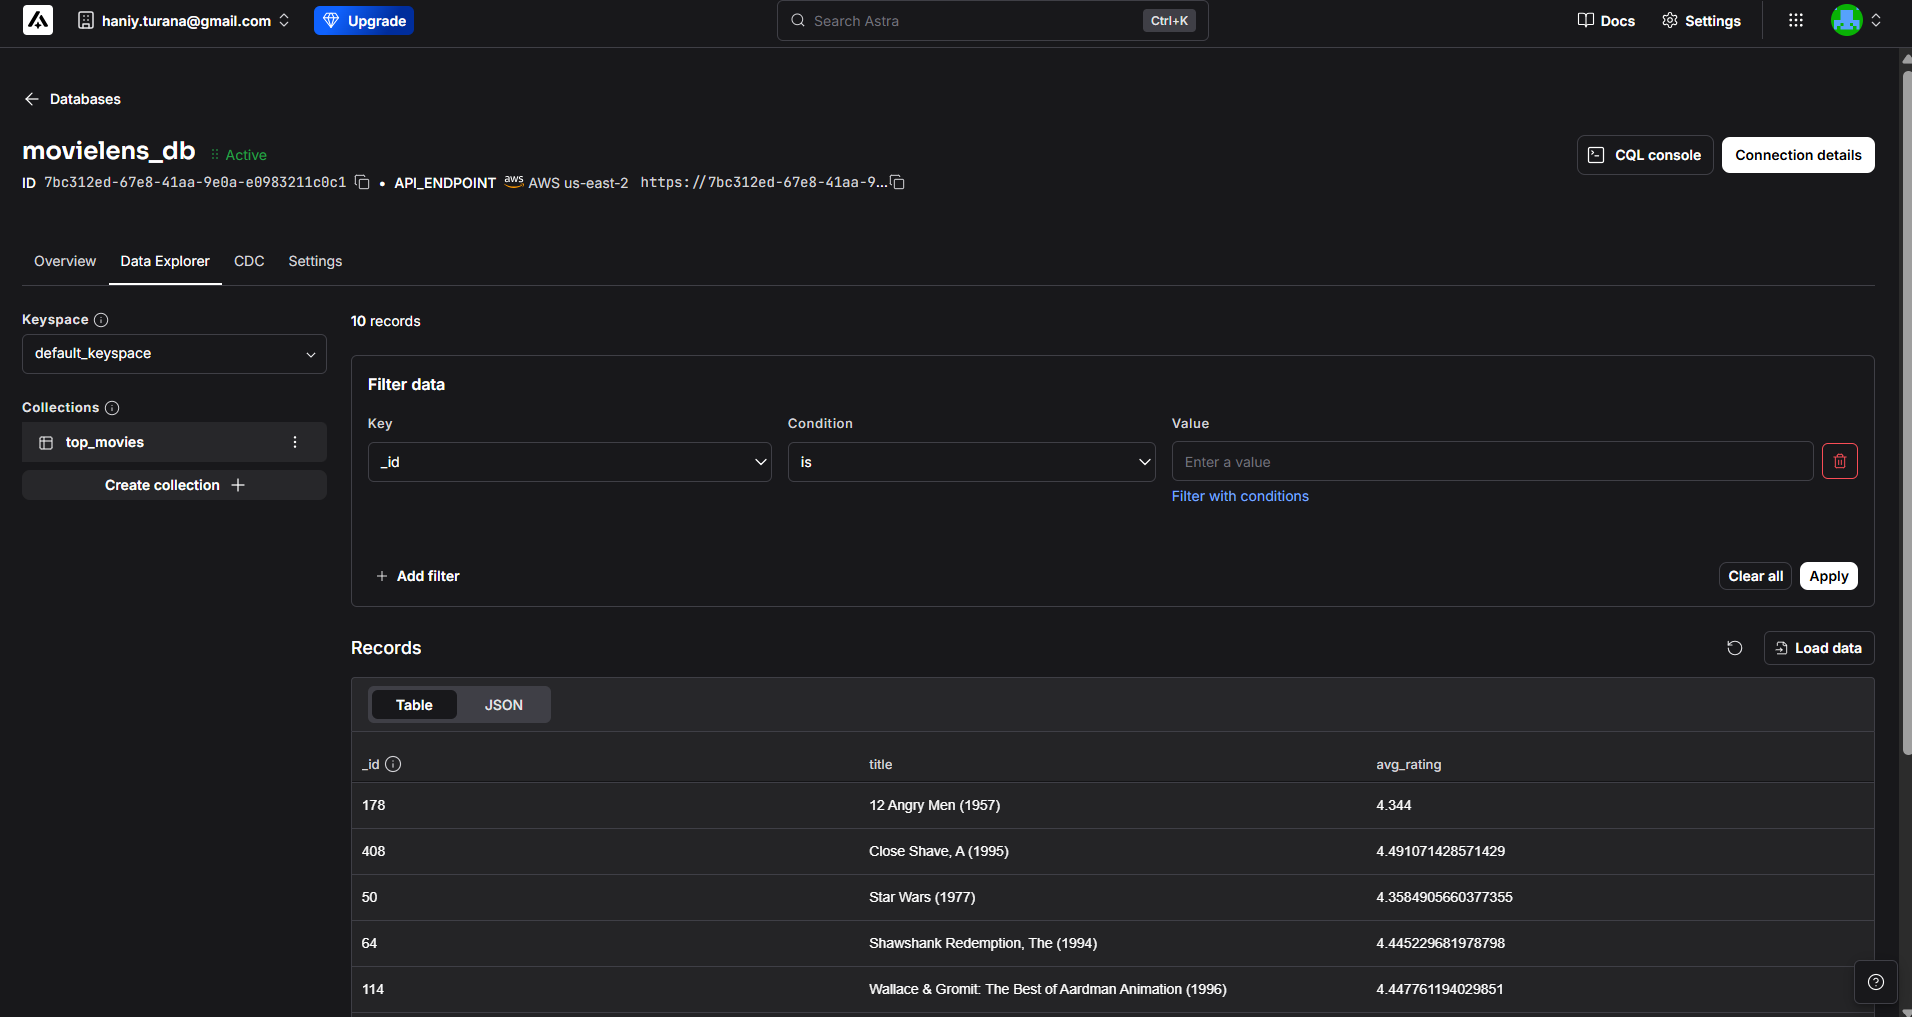


- From the image above, it confirms that our cloud data pipeline is 100% stable, secure network permissions are correctly configured, and all data records are fully active and safely stored on the external DataStax Astra DB Cloud platform.


In [ ]:
spark.stop()


**THE END**